# Import Liabraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load the datasets

In [5]:
import os
os.chdir("C:/Amdari_Dev/Kataoka/Kataoka_RUL_Project")

robots = pd.read_csv("data/raw/robot_units.csv")
sensor = pd.read_csv("data/raw/sensor_readings.csv")
maintenance = pd.read_csv("data/raw/maintenance_logs.csv")
failure = pd.read_csv("data/raw/failure_events.csv")

In [8]:
# Basic overview of the datasets
print("Robots:", robots.shape)
print("Sensor:", sensor.shape)
print("Maintenance:", maintenance.shape)
print("Failure:", failure.shape)

Robots: (50, 5)
Sensor: (76730, 7)
Maintenance: (262, 5)
Failure: (17, 5)


In [13]:
robots.head()


,robot_id,model_type,installation_date,factory_location,operating_environment
0,ROB-0001,ARM-X7,2023-01-07,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"
1,ROB-0002,ARM-X9,2023-02-05,Osaka Plant,"Clean Room (20-22°C, 40% RH)"
2,ROB-0003,ASSEMBLY-A3,2023-04-19,Osaka Plant,"Clean Room (20-22°C, 40% RH)"
3,ROB-0004,ARM-X7,2023-02-25,Tokyo Factory,"Clean Room (20-22°C, 40% RH)"
4,ROB-0005,ASSEMBLY-A3,2023-02-20,Hokkaido Lab,"Climate Controlled (22-25°C, 50% RH)"


In [14]:
sensor.head()

,reading_id,robot_id,timestamp,vibration_level,motor_temperature,torque_load,power_consumption
0,READ-000001,ROB-0001,2023-01-07 00:00:00,0.288,70.1,136.1,1471.0
1,READ-000002,ROB-0001,2023-01-07 06:00:00,0.135,70.2,139.5,811.1
2,READ-000003,ROB-0001,2023-01-07 12:00:00,0.277,47.9,123.5,752.5
3,READ-000004,ROB-0001,2023-01-07 18:00:00,0.172,58.2,111.2,610.9
4,READ-000005,ROB-0001,2023-01-08 00:00:00,0.465,52.8,68.2,1234.0


In [11]:
maintenance.head()

,maintenance_id,robot_id,maintenance_type,issue_detected,downtime_hours
0,MAINT-000001,ROB-0001,calibration,Minor wear detected,0.7
1,MAINT-000002,ROB-0001,lubrication,No issue found - routine check,3.1
2,MAINT-000003,ROB-0001,inspection,Minor wear detected,2.2
3,MAINT-000004,ROB-0001,lubrication,Minor wear detected,3.9
4,MAINT-000005,ROB-0001,inspection,No issue found - routine check,0.7


In [16]:
failure.head()

,failure_id,robot_id,failure_type,failure_time,root_cause
0,FAIL-0001,ROB-0018,bearing_failure,04/06/2024,electrical surge
1,FAIL-0002,ROB-0043,motor_failure,09/10/2023,lubrication breakdown
2,FAIL-0003,ROB-0032,overheating,04/15/2024,overload operation
3,FAIL-0004,ROB-0014,joint_wear,06/06/2023,thermal cycling fatigue
4,FAIL-0005,ROB-0035,encoder_drift,08/21/2023,electrical surge


In [21]:
# Datatypes and missing values
robots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   robot_id               50 non-null     object
 1   model_type             50 non-null     object
 2   installation_date      50 non-null     object
 3   factory_location       50 non-null     object
 4   operating_environment  50 non-null     object
dtypes: object(5)
memory usage: 2.1+ KB


In [26]:
robots.isnull().sum()

robot_id                 0
model_type               0
installation_date        0
factory_location         0
operating_environment    0
dtype: int64

In [23]:
sensor.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76730 entries, 0 to 76729
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   reading_id         76730 non-null  object        
 1   robot_id           76730 non-null  object        
 2   timestamp          76730 non-null  datetime64[ns]
 3   vibration_level    76730 non-null  float64       
 4   motor_temperature  76730 non-null  float64       
 5   torque_load        76730 non-null  float64       
 6   power_consumption  76730 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 4.7+ MB


In [27]:
sensor.isnull().sum()

reading_id           0
robot_id             0
timestamp            0
vibration_level      0
motor_temperature    0
torque_load          0
power_consumption    0
dtype: int64

In [24]:
maintenance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   maintenance_id    262 non-null    object 
 1   robot_id          262 non-null    object 
 2   maintenance_type  262 non-null    object 
 3   issue_detected    262 non-null    object 
 4   downtime_hours    262 non-null    float64
dtypes: float64(1), object(4)
memory usage: 10.4+ KB


In [28]:
maintenance.isnull().sum()

maintenance_id      0
robot_id            0
maintenance_type    0
issue_detected      0
downtime_hours      0
dtype: int64

In [25]:
failure.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   failure_id    17 non-null     object
 1   robot_id      17 non-null     object
 2   failure_type  17 non-null     object
 3   failure_time  17 non-null     object
 4   root_cause    17 non-null     object
dtypes: object(5)
memory usage: 812.0+ bytes


In [29]:
failure.isnull().sum()

failure_id      0
robot_id        0
failure_type    0
failure_time    0
root_cause      0
dtype: int64

In general, the datasets look clean with no missing values. The datatypes also seem appropriate for each column. We can now proceed to more detailed exploratory data analysis and feature engineering in the next steps.

In [17]:
# Sensor data distribution
sensor[['vibration_level','motor_temperature','torque_load','power_consumption']].describe()

,vibration_level,motor_temperature,torque_load,power_consumption
count,76730.000000,76730.000000,76730.000000,76730.000000
mean,0.345431,57.098948,105.013390,1296.795790
std,0.127222,9.097891,29.635359,436.006783
min,0.050000,34.800000,38.600000,449.100000
25%,0.243000,49.500000,79.700000,919.900000
50%,0.345000,57.100000,105.000000,1296.650000
75%,0.447000,64.600000,130.200000,1672.275000
max,0.771000,89.800000,183.000000,2303.100000


In [18]:
sensor['timestamp'] = pd.to_datetime(sensor['timestamp'])
sensor = sensor.sort_values('timestamp')

In [19]:
sensor.groupby('robot_id').size().head()

robot_id
ROB-0001    2161
ROB-0002    2045
ROB-0003    1753
ROB-0004    1965
ROB-0005    1985
dtype: int64

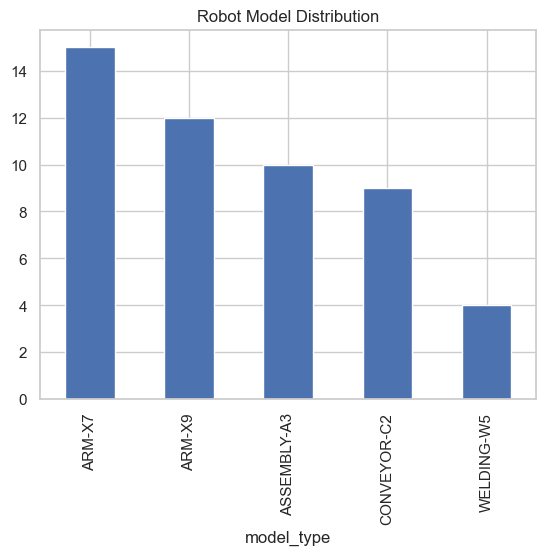

In [20]:
robots['model_type'].value_counts().plot(kind='bar')
plt.title("Robot Model Distribution")
plt.show()

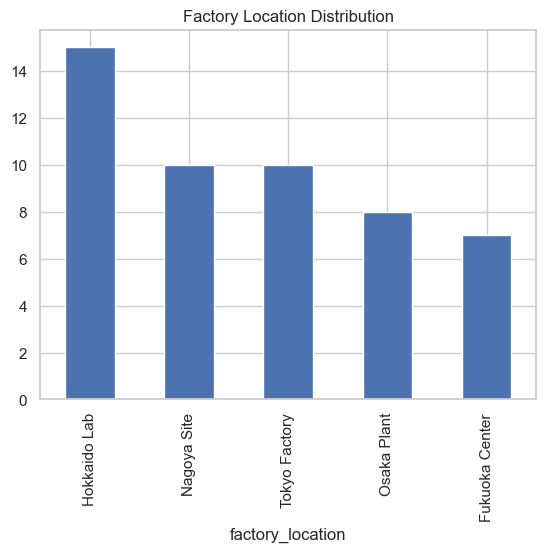

In [31]:
robots['factory_location'].value_counts().plot(kind='bar')
plt.title("Factory Location Distribution")
plt.show()

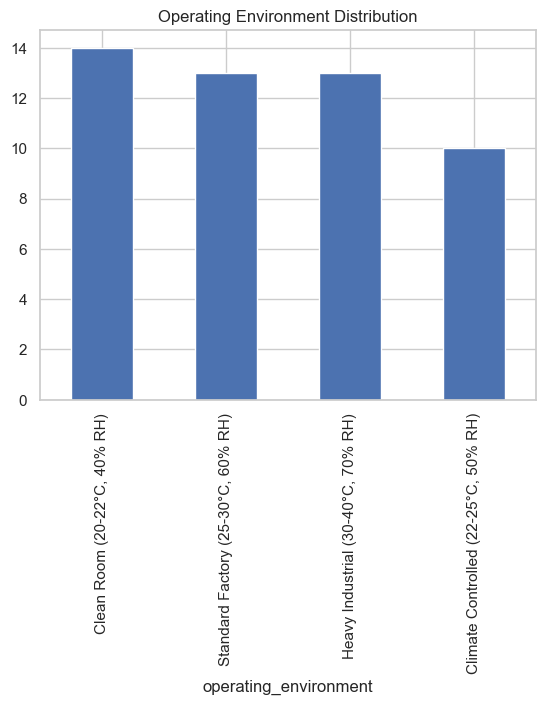

In [32]:
robots['operating_environment'].value_counts().plot(kind='bar')
plt.title("Operating Environment Distribution")
plt.show()

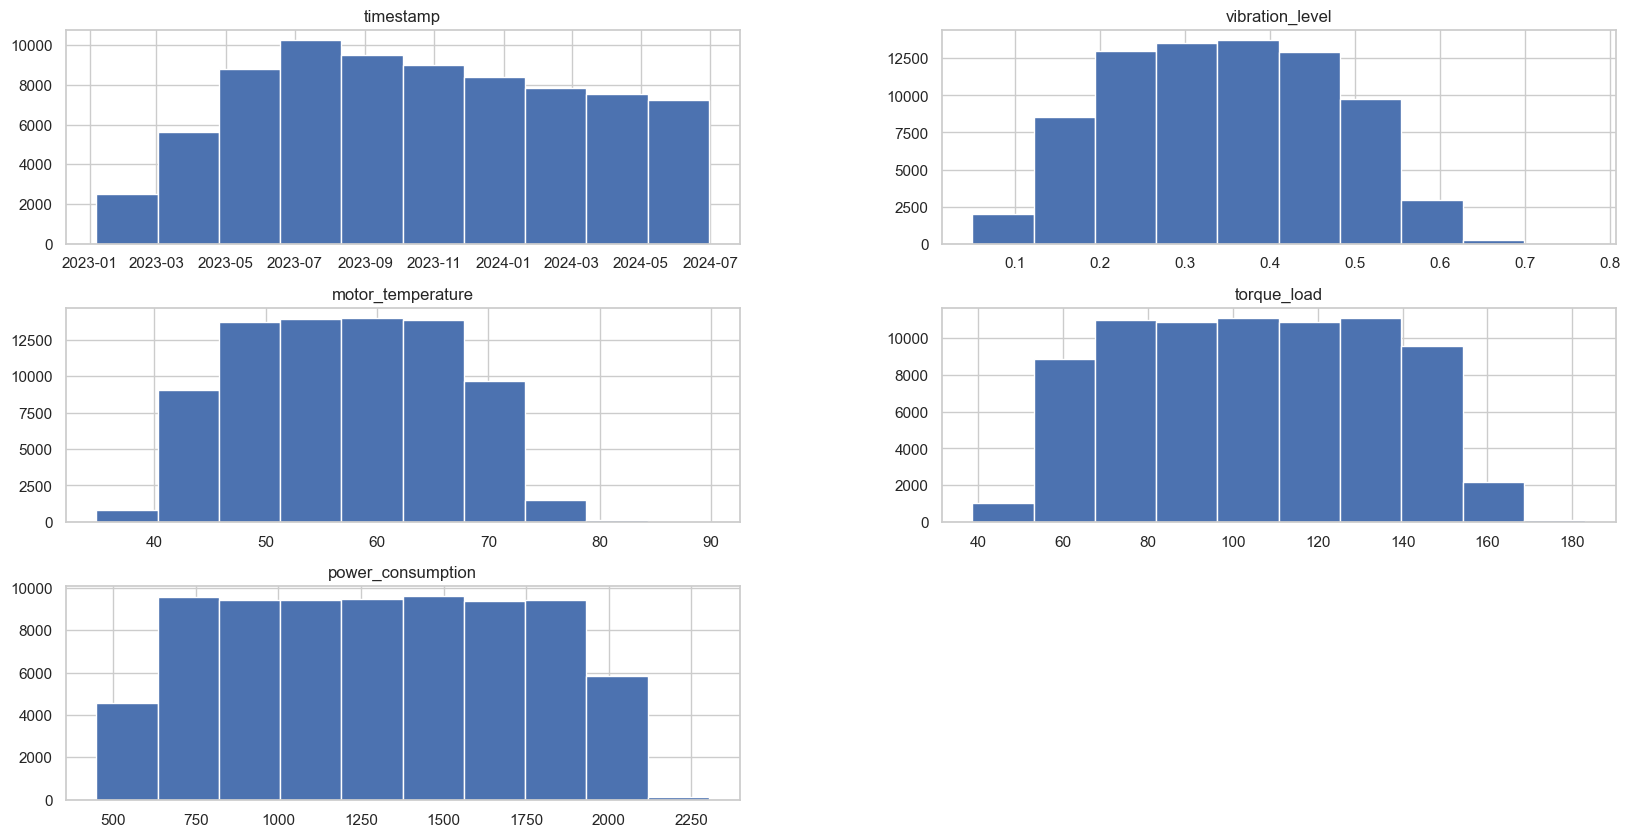

In [37]:
sensor.hist(figsize=(20,10))
plt.show()

In [39]:
maintenance['maintenance_type'].value_counts()

maintenance_type
calibration    86
inspection     83
lubrication    68
repair         16
replacement     9
Name: count, dtype: int64

In Summary: 

- Sensor readings are continuous and time-series in nature
- No timestamp in maintenance logs → requires reconstruction
- Failure events are sparse and unevenly distributed
- Vibration and temperature show variability suggesting degradation signals
- Some robots have no failure records → censored data

# Combined EDA insights

In [42]:
# Senor data merged with robot metadata
sensor_robot = sensor.merge(robots, on="robot_id", how="left")
sensor_robot.head()

,reading_id,robot_id,timestamp,vibration_level,motor_temperature,torque_load,power_consumption,model_type,installation_date,factory_location,operating_environment
0,READ-000001,ROB-0001,2023-01-07 00:00:00,0.288,70.1,136.1,1471.0,ARM-X7,2023-01-07,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"
1,READ-000002,ROB-0001,2023-01-07 06:00:00,0.135,70.2,139.5,811.1,ARM-X7,2023-01-07,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"
2,READ-000003,ROB-0001,2023-01-07 12:00:00,0.277,47.9,123.5,752.5,ARM-X7,2023-01-07,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"
3,READ-000004,ROB-0001,2023-01-07 18:00:00,0.172,58.2,111.2,610.9,ARM-X7,2023-01-07,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"
4,READ-000005,ROB-0001,2023-01-08 00:00:00,0.465,52.8,68.2,1234.0,ARM-X7,2023-01-07,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"


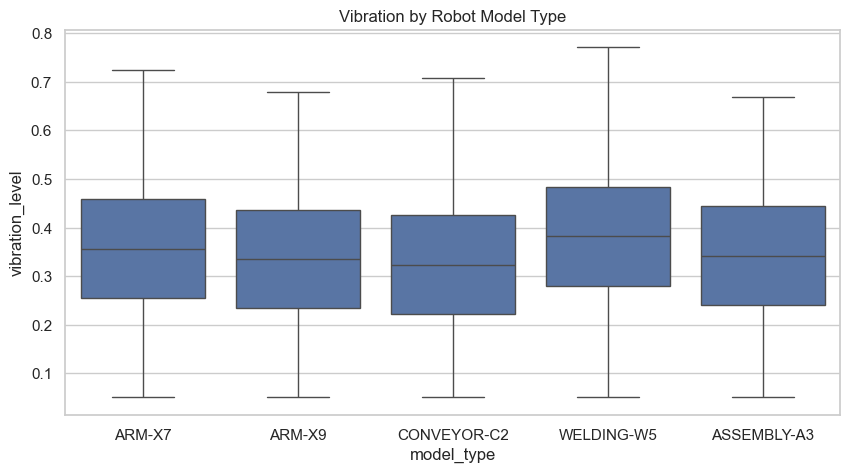

In [45]:
#Sensor behaviour by robot_model type
plt.figure(figsize=(10,5))
sns.boxplot(data=sensor_robot, x="model_type", y="vibration_level")
plt.title("Vibration by Robot Model Type")
plt.show()

Some robot models operate with higher vibration (Welding-W5)→ may indicate higher wear risk

In [46]:
# Merge sensor data with failure events to analyze sensor patterns before failures
failure['failure_time'] = pd.to_datetime(failure['failure_time'])
sensor['timestamp'] = pd.to_datetime(sensor['timestamp'])

sensor_failure = sensor.merge(failure, on="robot_id", how="left")

In [47]:
sensor_failure['time_to_failure'] = (
    sensor_failure['failure_time'] - sensor_failure['timestamp']
).dt.total_seconds() / 3600

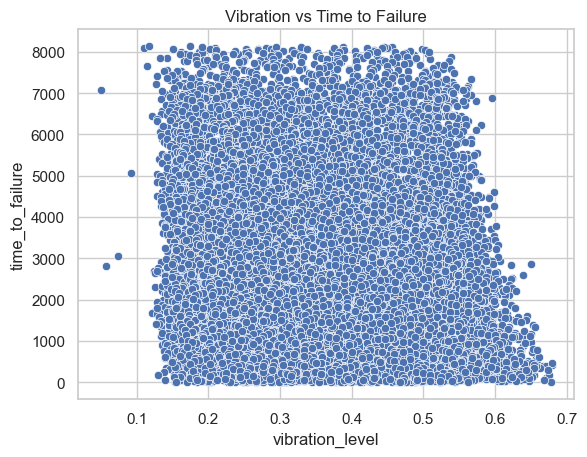

In [48]:
sns.scatterplot(
    data=sensor_failure,
    x="vibration_level",
    y="time_to_failure"
)
plt.title("Vibration vs Time to Failure")
plt.show()

Higher vibration correlates with shorter time to failure → strong degradation signal

In [49]:
# Merge sensor data with maintenance logs to analyze sensor patterns before maintenance events
sensor_maint = sensor.merge(maintenance, on="robot_id", how="left")

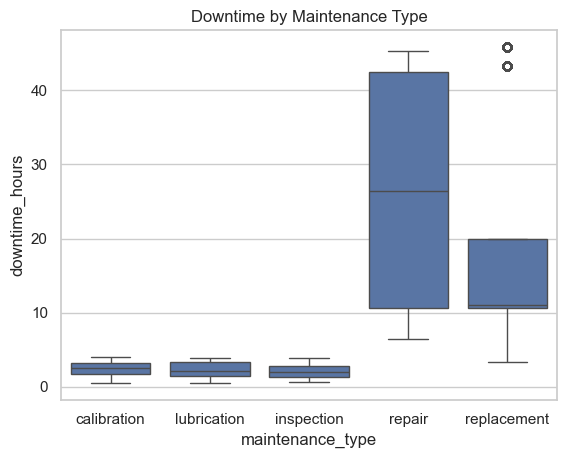

In [50]:
sns.boxplot(
    data=sensor_maint,
    x="maintenance_type",
    y="downtime_hours"
)
plt.title("Downtime by Maintenance Type")
plt.show()

Some maintenance types (especially repair & replacement) cause more downtime → opportunity to optimize maintenance strategy

In [51]:
# Full merge (all tables)
full_df = (
    sensor
    .merge(robots, on="robot_id", how="left")
    .merge(maintenance, on="robot_id", how="left")
    .merge(failure, on="robot_id", how="left")
)

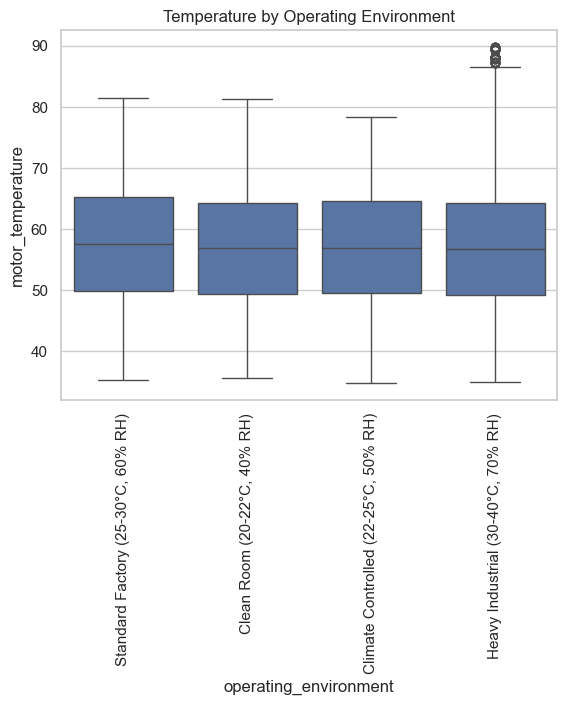

In [54]:
# Insights on operating environment and temperature patterns
sns.boxplot(
    data=full_df,
    x="operating_environment",
    y="motor_temperature"
)
plt.xticks(rotation=90)
plt.title("Temperature by Operating Environment")
plt.show()

Harsh environments lead to higher temperatures → accelerates degradation

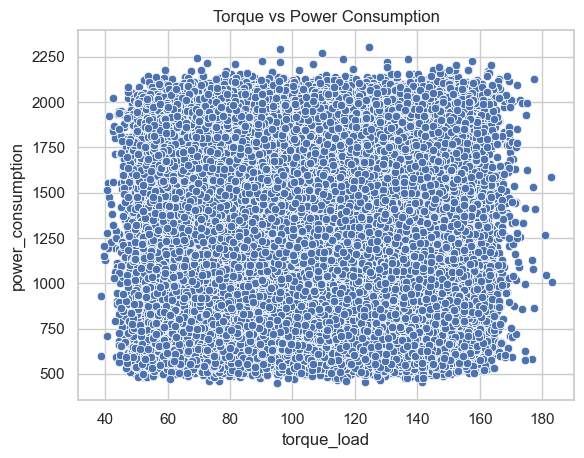

In [55]:
# Insights on Power vs Torque (Efficiency)
sns.scatterplot(
    data=full_df,
    x="torque_load",
    y="power_consumption"
)
plt.title("Torque vs Power Consumption")
plt.show()

Higher torque increases power consumption → indicates operational stress

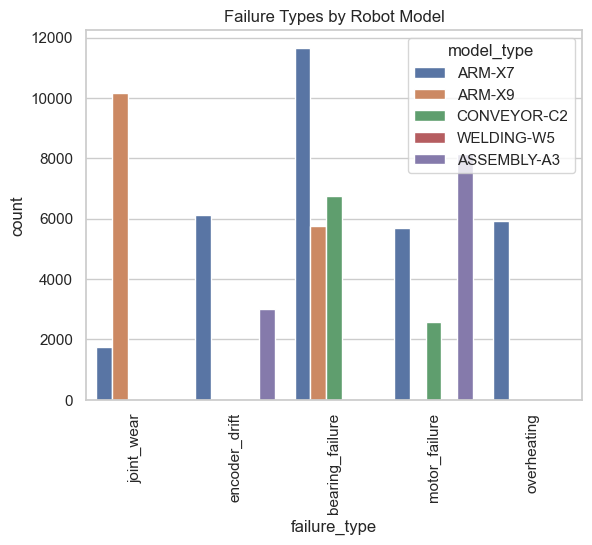

In [57]:
# Insight on Failure types by robot model
sns.countplot(
    data=full_df,
    x="failure_type",
    hue="model_type"
)
plt.xticks(rotation=90)
plt.title("Failure Types by Robot Model")
plt.show()

Certain robot models are more prone to specific failure types

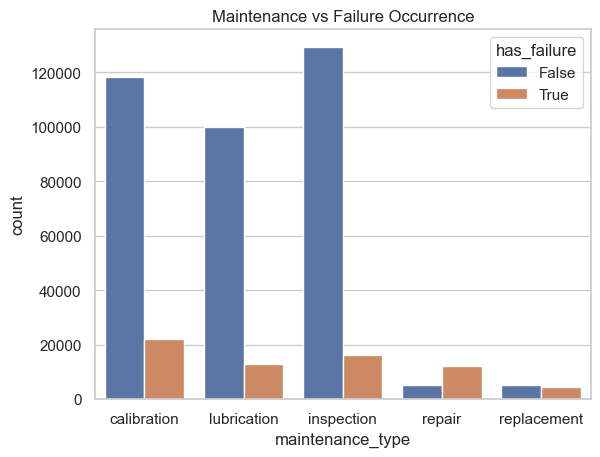

In [58]:
# Insight on Maintenance vs Failure Risk
full_df['has_failure'] = full_df['failure_type'].notnull()

sns.countplot(
    data=full_df,
    x="maintenance_type",
    hue="has_failure"
)
plt.title("Maintenance vs Failure Occurrence")
plt.show()

Some maintenance strategies are more effective in preventing failure

Summary of Combined EDA insights:
- Robot models exhibit different vibration patterns, indicating varying wear characteristics
- Higher vibration levels are associated with shorter time-to-failure
- Maintenance types vary in effectiveness and downtime impact
- Operating environment significantly influences temperature and degradation
- Torque and power consumption are strongly correlated, indicating operational stress
- Certain robot models are more susceptible to specific failure types
- Maintenance history impacts failure likelihood